# Wind Energy Prediction (Regression)

#### Step 1 :- Buisness Problem Understanding

- Predict/Estimate the wind energy based on atmospheric conditions

#### Step 2 :- Data Understanding & Data Exploration

- Load the Data from Data source
- Data Understanding
- Data Exploration

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_excel("energy2.xlsx")

In [3]:
df

,Temprature,Vaccum,Pressure,Humidity,Energy
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Temprature  9568 non-null   float64
 1   Vaccum      9568 non-null   float64
 2   Pressure    9568 non-null   float64
 3   Humidity    9568 non-null   float64
 4   Energy      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


- in this data we dont have any null values and all the data types is Float

In [9]:
df.shape

(9568, 5)

- This Data have 9568 rows and 5 columns

In [11]:
df.duplicated().sum()

41

In [14]:
df[df.duplicated()]

,Temprature,Vaccum,Pressure,Humidity,Energy
2184,9.54,41.17,1019.79,65.61,481.18
2421,12.11,41.17,1019.46,62.59,475.53
2577,28.84,75.60,1018.41,53.96,442.69
2896,27.54,75.60,1018.26,57.89,440.87
3314,8.07,41.17,1019.40,86.43,484.54
4236,25.79,75.60,1017.46,75.63,434.65
4549,11.23,41.17,1019.36,56.85,475.85
4577,24.63,59.57,1010.45,85.36,440.67
4667,25.21,75.60,1017.19,69.84,445.84
5276,25.56,75.60,1017.37,69.31,442.20


- there are no exact duplicate values 

#### Step 3 :- Data Preperation

- Data cleaning
- Data Transformation
- creat input & output variables
- Spliting the Data into Train set and Test set

- This is a cleaned data so no Data Cleaning and data transformation

**input & output variables**

In [17]:
x = df.drop(columns = "Energy")
y = df["Energy"]

In [18]:
x

,Temprature,Vaccum,Pressure,Humidity
0,14.96,41.76,1024.07,73.17
1,25.18,62.96,1020.04,59.08
2,5.11,39.40,1012.16,92.14
3,20.86,57.32,1010.24,76.64
4,10.82,37.50,1009.23,96.62
...,...,...,...,...
9563,16.65,49.69,1014.01,91.00
9564,13.19,39.18,1023.67,66.78
9565,31.32,74.33,1012.92,36.48
9566,24.48,69.45,1013.86,62.39


In [19]:
y

0       463.26
1       444.37
2       488.56
3       446.48
4       473.90
         ...  
9563    460.03
9564    469.62
9565    429.57
9566    435.74
9567    453.28
Name: Energy, Length: 9568, dtype: float64

**Spliting the Data into Train set and Test set**

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 100)

In [21]:
x_train

,Temprature,Vaccum,Pressure,Humidity
8948,14.12,41.39,1018.73,76.51
7519,20.10,58.95,1018.46,80.87
29,30.53,65.18,1012.69,41.85
627,12.24,44.92,1023.74,88.21
6220,31.16,64.96,1001.71,44.85
...,...,...,...,...
350,26.48,69.14,1009.31,84.11
79,27.66,76.86,1001.31,69.47
8039,18.78,63.09,1019.22,80.20
6936,10.22,39.16,1015.71,96.20


- This is input train data (80%)

In [22]:
x_test

,Temprature,Vaccum,Pressure,Humidity
2708,27.09,73.50,1011.34,76.06
6408,9.26,44.68,1023.22,91.44
435,9.43,37.14,1013.03,74.99
5777,6.30,41.14,1027.45,86.11
2863,20.70,58.16,1016.73,68.19
...,...,...,...,...
4829,16.23,43.69,1016.40,68.90
8746,26.33,61.41,1011.90,52.10
4341,14.66,42.07,1018.14,84.68
2524,27.14,75.23,1011.47,63.14


- This is input test data (20%)

In [23]:
y_train

8948    472.88
7519    446.70
29      437.89
627     473.26
6220    425.82
         ...  
350     435.76
79      436.64
8039    452.86
6936    478.45
5640    462.30
Name: Energy, Length: 7654, dtype: float64

- This is output train data (80%)

In [25]:
y_test

2708    434.31
6408    478.82
435     473.57
5777    481.49
2863    453.22
         ...  
4829    466.22
8746    452.79
4341    462.77
2524    439.33
6775    456.97
Name: Energy, Length: 1914, dtype: float64

- This is output test data (20%)

#### Step 4 :- Modeling (Perceptron)

- Design of Network

In [26]:
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import Dense

**Design the Percepron model**

- initialization of perceptron model

In [28]:
p_model = Sequential()
p_model.add(Dense(input_dim = 4, units = 1, activation = "relu", kernel_initializer = "uniform")) 

C:\Users\Ankit\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- compile

In [31]:
p_model.compile(optimizer = "adam", loss = "mean_squared_error")

- fit the train data

In [32]:
p_model.fit(x_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 107331.0000
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19541.1406
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2291.4727
Epoch 4/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 546.7210
Epoch 5/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 458.3439
Epoch 6/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 448.9393
Epoch 7/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 439.5979
Epoch 8/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 429.0267
Epoch 9/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 417.1917
Epoch 10/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 404.2399
Epoch 11/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 390.0121
Epoch 12/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 374.6953
Epoch 13/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 358.3403
Epoch 14/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 340.7085
Epoch 15/

**predict on train data**

In [34]:
y_train_predicted = p_model.predict(x_train)

240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


- Done predicting Train output Value

In [36]:
y_train_predicted

array([[468.58252],
       [453.17667],
       [434.99435],
       ...,
       [454.69315],
       [472.25256],
       [472.774  ]], dtype=float32)

- This is the Predicted Output Value of Train Data

**Predict on test data**

In [38]:
y_test_predicted = p_model.predict(x_test)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


- Done predicting Test output Value

#### Step 5 :- Evaluation

- Train RMSE
- Test RMSE

**Train RMSE**

In [48]:
from sklearn.metrics import mean_squared_error

In [49]:
train_mse = mean_squared_error(y_train, y_train_predicted)

In [50]:
train_rmse = np.sqrt(train_mse)

In [51]:
print("Train RMSE =", train_rmse)

Train RMSE = 5.097985720208411


- This is Train RMSE 

**Test RMSE**

In [52]:
test_mse = mean_squared_error(y_test, y_test_predicted)

In [53]:
test_rmse = np.sqrt(test_mse)

In [54]:
print("Test RMSE =", test_rmse)

Test RMSE = 5.3367939201986


- This is Test RMSE

#### Step 6 :- Calculate R2 Score

In [59]:
from sklearn.metrics import r2_score

In [62]:
print("Train R2 Score =", r2_score(y_train, y_train_predicted))

Train R2 Score = 0.9104243928412425


In [64]:
print("Test R2 Score =", r2_score(y_test, y_test_predicted))

Test R2 Score = 0.9036789794518207


#### Step 7 :- Plot

In [71]:
import matplotlib.pyplot as plt

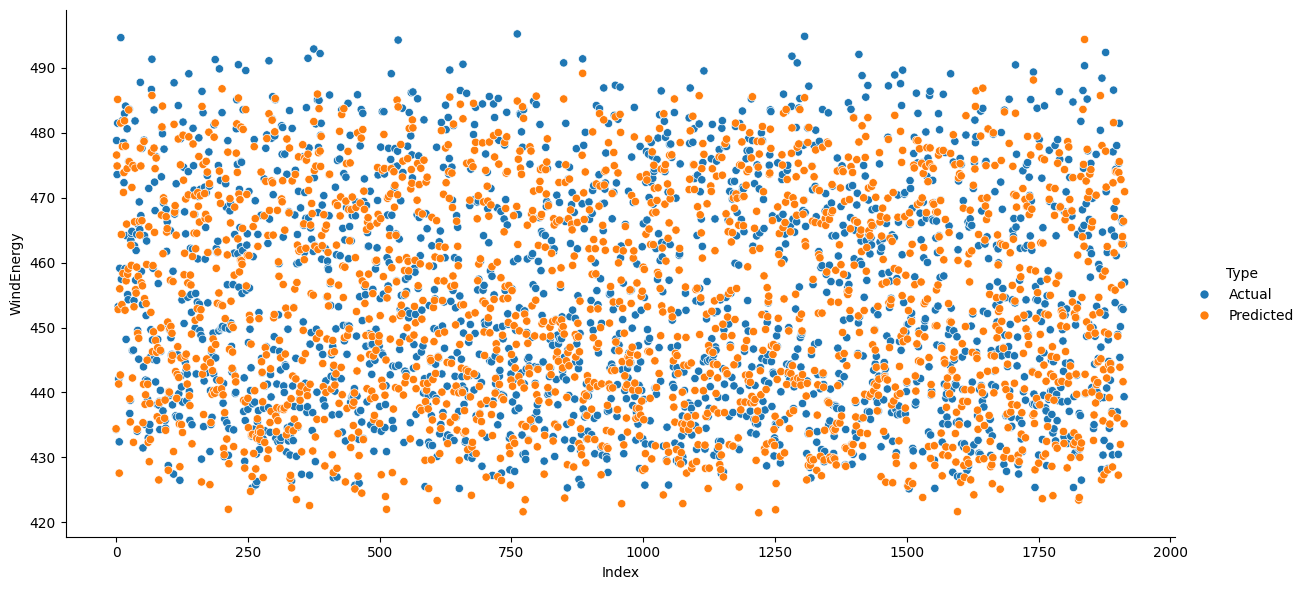

In [87]:
import seaborn as sns

df_plot = pd.DataFrame({
    'Index': range(len(y_test)),
    'Actual': y_test.values.flatten(),
    'Predicted': y_test_predicted.flatten()
})

df_long = df_plot.melt(
    id_vars='Index',
    value_vars=['Actual', 'Predicted'],
    var_name='Type',
    value_name='WindEnergy'
)

sns.relplot(
    data=df_long,
    x='Index',
    y='WindEnergy',
    hue='Type',
    kind='scatter',
    height=6,
    aspect=2
)

#### Step 8 :- Conclusion


* Developed a Wind Energy Prediction model using an Artificial Neural Network (ANN).
* Achieved a Train R² Score of **91.04%** and a Test R² Score of **90.37%**, showing strong prediction performance.
* Obtained a Test RMSE of **5.34**, indicating a low prediction error.
* The training and testing results were very close, which suggests the model generalizes well and is not overfitting.
* The Actual vs Predicted plots showed that most predictions were close to the actual wind energy values.
* This model can help in forecasting wind energy production and supporting renewable energy planning.
* Future improvements can include testing advanced models and deploying the solution as a real-time prediction application.
